# Gold Layer — Model Training, Events & Match Reports

Welcome to the **Gold layer**, the top of the pipeline. Silver hands us a state
tuple per frame — health, aggression, defense, domain readiness — and Gold
answers the questions the design document cares about:

1. **Is the player winning, losing, or in a stalemate?** (text classification)
2. **What *happened* in the match?** (the event layer turns state deltas into
   hits, whiffs, punishes, round outcomes, and domain alerts)
3. **How good was the player?** (the report: a 0-100 score, headline stats,
   timeline JSON, and a shareable stat card)
4. **Which is the best classifier?** (the model zoo, ranked, under MLflow)

Every match you process is one MLflow run carrying params (VOD file + event
thresholds), metrics (event counts, mean OCR confidence) and artifacts
(timeline JSON + stat card) — and the winning classifier is registered in the
model registry so it can be promoted to production without losing history.

## Where are we in the pipeline?

```
Raw VOD  ->  [BRONZE]  ->  [SILVER]  ->  [GOLD]  ->  Report Card
             denoise,     HUD-ground    (you are     winning/losing
             sampled frames per-frame    here)       stalemate + events
             to standard size  state tuples              + score

```


## Setup: Imports & Paths

In [1]:
import sys
from pathlib import Path

NOTEBOOKS_DIR = Path(r"/mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/notebooks")

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE

from src.config import BRONZE_DIR, SILVER_DIR
from src.pipeline.bronze import process_image as bronze_process
from src.pipeline.events_gold import EVENT_TYPES, detect_events
from src.pipeline.gold import (
    FEATURE_NAMES,
    STATE_LABELS,
    features_to_vector,
    generate_synthetic_dataset,
    load_labeled_dataset,
    predict,
    process_vod_report,
    rule_based_label,
    train_and_compare,
    train_gold_model,
)
from src.pipeline.model_registry import (
    list_state_reader_versions,
    load_state_reader,
    register_state_reader,
    transition_state_reader_version,
)
from src.pipeline.report import build_headline, compute_score

sns.set_theme(style="darkgrid")
%matplotlib inline

---
# Part 1: The Classification Problem

The Gold layer ignores pixels entirely. It consumes the structured feature
vector produced by the Silver layer:

| # | Feature             | Meaning                                    |
|---|---------------------|--------------------------------------------|
| 1 | `player_health`    | Player's remaining health (0..1)           |
| 2 | `mean_enemy_health` | Average health of detected enemies        |
| 3 | `min_enemy_health` | Health of the weakest enemy               |
| 4 | `health_ratio`     | player_health / mean_enemy_health         |
| 5 | `num_enemies`      | How many enemies are on screen            |
| 6 | `is_attacking`     | Is the player attacking? (0/1)            |
| 7 | `defending`        | Is the player defending? (0/1)            |
| 8 | `damage_indicator` | Is the player taking damage? (0/1)        |

Every screenshot becomes one 8-dimensional vector. The classifier maps that
vector to one of three plain-English labels:

- **winning** — the player has the advantage (health ratio + aggression)
- **losing** — the player is at a disadvantage (low health, taking damage)
- **stalemate** — roughly even

### Why a separate classifier?

The Silver CNN answers "*what is on screen?*" (perception). The Gold classifier
answers "*who is winning?*" (reasoning) — and then the **event layer** answers
"*what happened?*". Two — well, three — different problems, separated so each
can be debugged independently.


---
# Part 2: The Rule-Based Labeler (Free Labels)

Until human labels arrive, `rule_based_label()` generates them deterministically
from the features, mirroring the AGENTS.md definition of each state. The rules
are checked in priority order:

1. **losing** — player health < 0.2, OR health ratio <= 0.7, OR taking damage
   below half health
2. **winning** — health ratio >= 1.3 while not defending, OR attacking with a
   positive health ratio
3. **stalemate** — everything else

These rules prime a training set that a human can verify faster than they can
label from scratch.

In [2]:
winning_example = {
    "image_path": "/synthetic/frame_0000.png",
    "player_health": 0.8,
    "player_position": [0.5, 0.5],
    "enemies": [{"bbox": [100, 200, 60, 60], "health": 0.3,
                 "health_bar_bbox": [100, 170, 50, 8], "confidence": 0.9}],
    "attacking": True,
    "defending": False,
    "damage_indicator": False,
    "num_enemies": 1,
}

losing_example = {
    "image_path": "/synthetic/frame_0001.png",
    "player_health": 0.2,
    "player_position": [0.5, 0.5],
    "enemies": [{"bbox": [100, 200, 60, 60], "health": 0.9,
                 "health_bar_bbox": [100, 170, 50, 8], "confidence": 0.9}],
    "attacking": False,
    "defending": True,
    "damage_indicator": True,
    "num_enemies": 1,
}

stalemate_example = {
    "image_path": "/synthetic/frame_0002.png",
    "player_health": 0.5,
    "player_position": [0.5, 0.5],
    "enemies": [{"bbox": [100, 200, 60, 60], "health": 0.5,
                 "health_bar_bbox": [100, 170, 50, 8], "confidence": 0.9}],
    "attacking": False,
    "defending": False,
    "damage_indicator": False,
    "num_enemies": 1,
}

for name, example in [("winning", winning_example),
                      ("losing", losing_example),
                      ("stalemate", stalemate_example)]:
    vec = features_to_vector(example)
    print(f"{name:10s} -> {rule_based_label(example):10s} "
          f"health_ratio={vec[FEATURE_NAMES.index('health_ratio')]:.3f}")

winning    -> winning    health_ratio=2.667
losing     -> losing     health_ratio=0.222
stalemate  -> stalemate  health_ratio=1.000


---
# Part 3: Generating a Synthetic Labeled Dataset

`generate_synthetic_dataset()` creates a fully labeled dataset for pipeline
testing. Every sample is a SilverFeatures dict; classes are **stratified** so
all three states always appear. This is the exact layout real labeled data will
use:

```
dataset/
    silver/*.json    # feature dicts + embedded "label" key
    labels.csv       # stem,label — the human-editable source of truth
```

In [3]:
dataset_root = generate_synthetic_dataset(
    str(Path(tempfile.mkdtemp()) / "ds"), num_samples=300, seed=42)
print(f"Dataset written to: {dataset_root}")

X, y, stems = load_labeled_dataset(dataset_root)
labels = pd.Series([STATE_LABELS[i] for i in y])
print(f"\nFeature matrix: {X.shape}  (300 screenshots x {X.shape[1]} features)")
print("\nClass balance:")
print(labels.value_counts().to_string())

Dataset written to: /tmp/tmpa5q50n3y/ds

Feature matrix: (300, 8)  (300 screenshots x 8 features)

Class balance:
winning      113
stalemate     97
losing        90


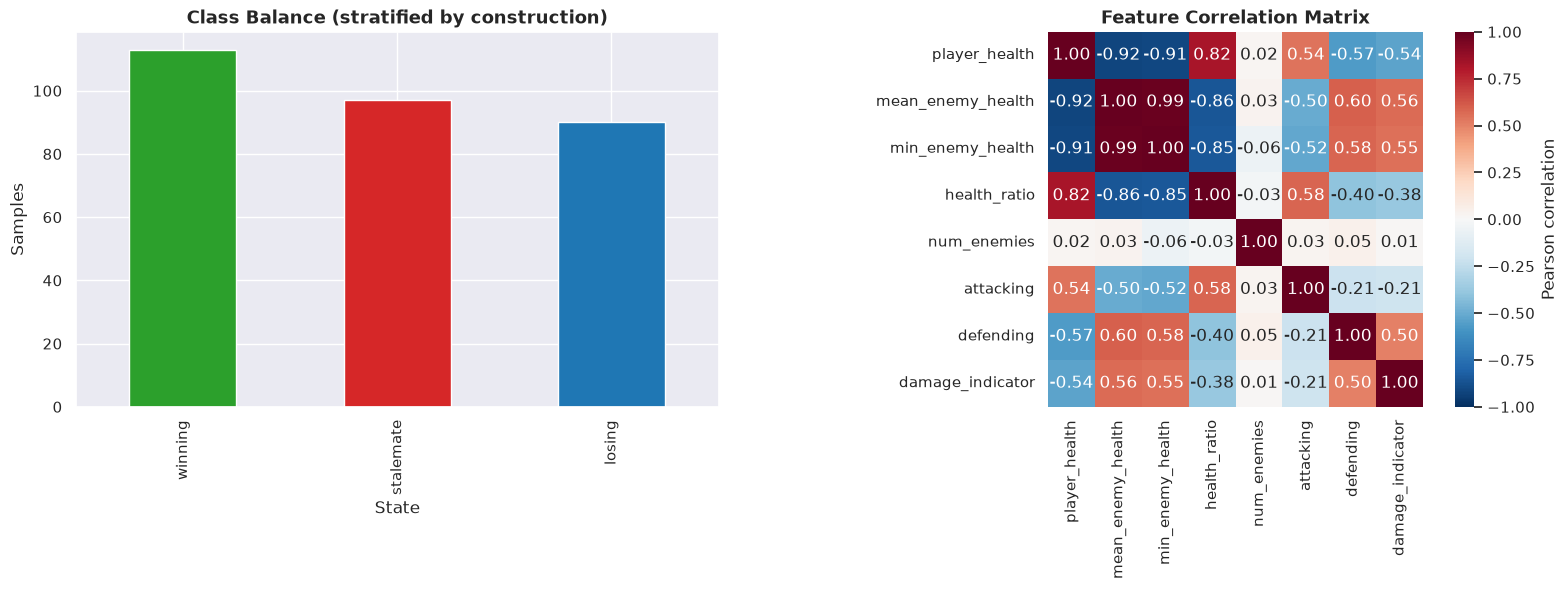

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels.value_counts().plot(kind="bar", ax=axes[0],
                           color=["#2ca02c", "#d62728", "#1f77b4"])
axes[0].set_title("Class Balance (stratified by construction)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Samples")
axes[0].set_xlabel("State")

feature_df = pd.DataFrame(X, columns=FEATURE_NAMES)
sns.heatmap(feature_df.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=axes[1], square=True,
            cbar_kws={"label": "Pearson correlation"})
axes[1].set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

---
# Part 4: Real Data — How Labels Get Attached

For real screenshots you attach a label to each Silver JSON two ways:

1. **labels.csv** — one `stem,label` row per screenshot.
2. **Embedded `label` key** — inside the Silver JSON.

`load_labeled_dataset()` reads both: the CSV **overrides** the embedded label,
and any sample without a label raises a clear error naming the missing stem.

In [5]:
labels_csv = Path(dataset_root) / "labels.csv"
print(pd.read_csv(labels_csv).head(8).to_string(index=False))
print(f"\n{len(list(Path(dataset_root).glob('silver/*.json')))} silver JSONs, "
      f"{len(pd.read_csv(labels_csv))} label rows")

      stem     label
frame_0000   winning
frame_0001 stalemate
frame_0002    losing
frame_0003   winning
frame_0004 stalemate
frame_0005 stalemate
frame_0006    losing
frame_0007   winning

300 silver JSONs, 300 label rows


---
# Part 5: Training One Classifier with MLflow

Every training run is tracked: **params** (model name, seed, split sizes),
**metrics** (accuracy, macro/weighted F1), **artifacts** (confusion matrix,
classification report, saved model).

In [6]:
result = train_gold_model(
    dataset_root,
    model_name="random_forest",
    experiment_name="gold_demo",
    run_name="demo_random_forest",
    val_split=0.2,
    seed=42,
)
print(f"\nRun ID    : {result['run_id']}")
print(f"Accuracy  : {result['accuracy']:.4f}")
print(f"Macro F1  : {result['macro_f1']:.4f}")
print(f"Model at  : {result['model_path']}")

2026/08/06 15:32:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/06 15:32:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


random_forest           acc=1.000  macro_f1=1.000  run=dbf2ad4ce9244a588469ef2fcb30088e

Run ID    : dbf2ad4ce9244a588469ef2fcb30088e
Accuracy  : 1.0000
Macro F1  : 1.0000
Model at  : models:/m-c080b0c73cc54bef87cbd42c7defd7db


## Predicting with the Trained Model

`predict()` consumes a SilverFeatures dict (or a raw vector) and returns the
label plus probabilities for **all three** states.

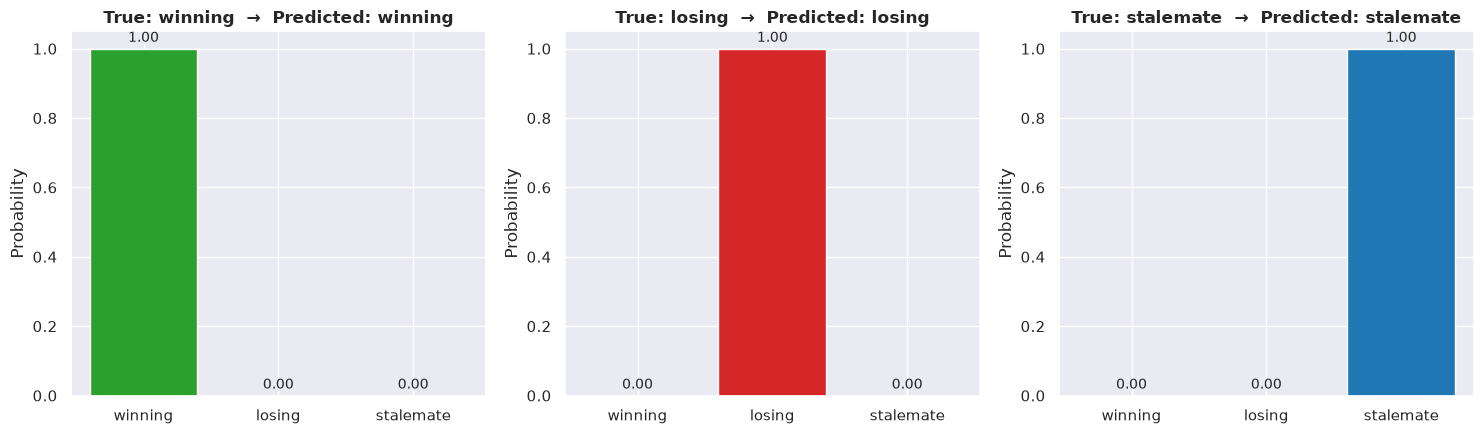

In [7]:
import mlflow

model = mlflow.sklearn.load_model(result["model_path"])

examples = [("winning", winning_example),
            ("losing", losing_example),
            ("stalemate", stalemate_example)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (true_label, example) in zip(axes, examples):
    predicted, probs = predict(example, model)
    bars = ax.bar(list(probs.keys()), list(probs.values()),
                  color=["#2ca02c", "#d62728", "#1f77b4"])
    ax.set_title(f"True: {true_label}  →  Predicted: {predicted}",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
    for bar, value in zip(bars, probs.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{value:.2f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

---
# Part 6: The Model Zoo — Finding the Best Fit

AGENTS.md requires MLflow to test a **wide variety** of models:

| Model                 | Why it might win                   |
|-----------------------|------------------------------------|
| `logistic_regression` | Baseline; the features are simple  |
| `random_forest`       | Handles threshold boundaries well  |
| `gradient_boosting`   | Strong on small tabular data       |
| `xgboost`             | State-of-the-art gradient boosting |
| `svc`                 | Great with scaled, separable data  |
| `pytorch_mlp`         | Deep learning entry                |

`train_and_compare()` races all six, then writes a **leaderboard** run with the
ranking, the feature correlation matrix, and a t-SNE embedding.

In [8]:
leaderboard = train_and_compare(
    dataset_root,
    experiment_name="gold_demo",
    model_params=None,  # each model's default hyperparameters
    val_split=0.2,
    seed=42,
)
print(leaderboard[["model_name", "accuracy", "macro_f1", "weighted_f1"]].to_string(index=False))

2026/08/06 15:32:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/06 15:32:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


logistic_regression     acc=1.000  macro_f1=1.000  run=c619c89ae1794ed7ae44ffa2ce326ec3


2026/08/06 15:32:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/06 15:32:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

svc                     acc=1.000  macro_f1=1.000  run=6c8ad04905ee4a89b6be69fee74971fa


2026/08/06 15:33:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/06 15:33:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


pytorch_mlp             acc=1.000  macro_f1=1.000  run=b2a202f15df4485fa7f3b84f04690876


         model_name  accuracy  macro_f1  weighted_f1
logistic_regression       1.0       1.0          1.0
      random_forest       1.0       1.0          1.0
  gradient_boosting       1.0       1.0          1.0
            xgboost       1.0       1.0          1.0
                svc       1.0       1.0          1.0
        pytorch_mlp       1.0       1.0          1.0


/tmp/ipykernel_25972/2695642663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leaderboard, x="model_name", y="macro_f1", ax=ax,


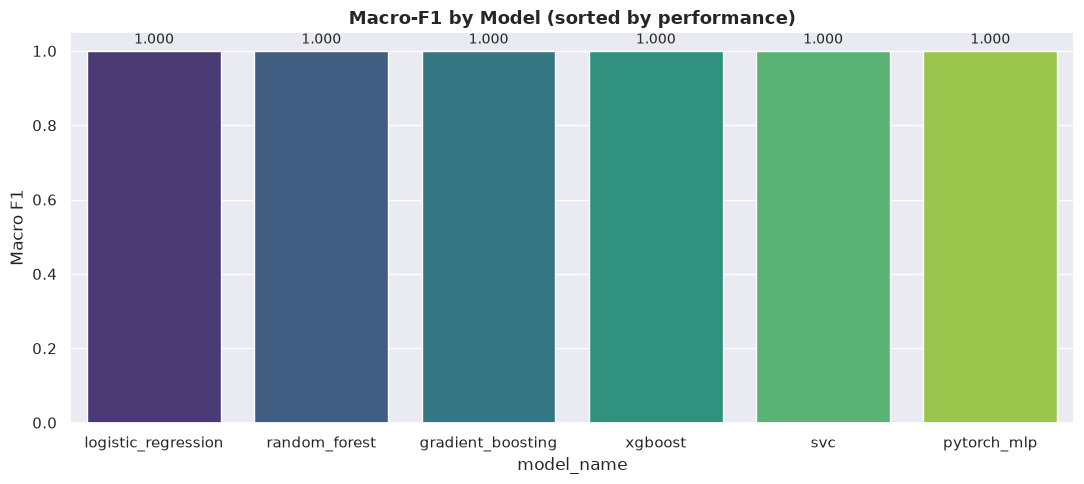

Best model: logistic_regression (macro_f1=1.000)


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=leaderboard, x="model_name", y="macro_f1", ax=ax,
            order=leaderboard["model_name"], palette="viridis")
ax.set_title("Macro-F1 by Model (sorted by performance)", fontsize=13, fontweight="bold")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
for i, row in enumerate(leaderboard.itertuples()):
    ax.text(i, row.macro_f1 + 0.02, f"{row.macro_f1:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print(f"Best model: {leaderboard.iloc[0]['model_name']} "
      f"(macro_f1={leaderboard.iloc[0]['macro_f1']:.3f})")

---
# Part 7: The Event Layer — State-Delta Events

A classifier tells you the *state*; the **event layer** tells you the *story*.
`detect_events()` diffs consecutive state tuples. Per AGENTS.md:

| Delta between frames            | Event          |
|----------------------------------|----------------|
| Enemy health drops ≥ threshold   | `hit_landed` (a hit landed) |
| Player health drops ≥ threshold  | `hit_taken` (player got hit) |
| Hit landed, **no return hit**    | `punish` (free damage)       |
| Attack start with no landing     | `whiff`                      |
| Player health hits zero          | `round_loss`                 |
| Enemy health hits zero           | `round_win`                  |
| Domain ready rising edge         | `domain_alert` (domain deployed) |

Round boundaries are detected via Silver's `round_index` (or a >0.5 health
reset), and the health reset itself is *not* treated as a hit.

Let's process a simulated stream: we contact a mini-match by hand so we know
exactly what it contains.

In [10]:
def frame(i, ph, eh, attacking=False, domain=False, r=0):
    """A single SilverFeatures-style state dict, hand-staged for the demo."""
    return {
        "frame_index": i,
        "timestamp_sec": i / 30.0,
        "round_index": r,
        "ocr_confidence": 0.97,
        "player_health": ph,
        "player_position": [0.5, 0.5],
        "num_enemies": len(eh),
        "attacking": attacking,
        "defending": False,
        "damage_indicator": False,
        "domain_ready": domain,
        "clock_sec": 60.0 - i,
        "image_path": f"/demo/frame_{i:04d}.png",
        "enemies": [{"bbox": [100, 200, 60, 60], "health": h,
                     "health_bar_bbox": [100, 170, 50, 8],
                     "confidence": 0.9} for h in eh],
    }

demo_states = [
    frame(0, 1.0, [0.8], r=0), frame(1, 1.0, [0.8], attacking=True, r=0),
    frame(2, 1.0, [0.55], r=0),               # round 1: a clean hit
    frame(3, 0.75, [0.55], r=0),              # ... returned immediately
    frame(4, 0.75, [0.25], r=0), frame(5, 0.30, [0.25], r=0),
    frame(6, 0.05, [0.25], r=0),              # round 1 loss
    frame(7, 1.0, [0.8], r=1), frame(8, 1.0, [0.8], attacking=True, r=1),
    frame(9, 1.0, [0.8], attacking=True, r=1),
    frame(10, 1.0, [0.2], domain=True, r=1),  # punish + domain deployed
    frame(11, 1.0, [0.0], r=1), frame(12, 1.0, [0.0], r=1),  # round 1 win
    frame(13, 1.0, [0.8], r=2),
    frame(14, 1.0, [0.8], attacking=True, r=2),  # a whiff...
    frame(15, 0.6, [0.8], r=2),
    frame(16, 0.05, [0.8], r=2),              # round 2 loss
    frame(17, 1.0, [0.8], r=3),
]

events = detect_events(demo_states, punish_window_frames=3)
print(f"{len(events)} events detected:\n")
print(f"{'type':<12} {'frame':>5} {'detail'}")
print("-" * 60)
for event in events:
    print(f"{event.type:<12} {event.frame_index:>5} {event.detail}")

16 events detected:

type         frame detail
------------------------------------------------------------
hit_landed       2 {'target': 'enemy', 'health_before': 0.8, 'health_after': 0.55, 'damage': 0.25}
hit_taken        3 {'target': 'player', 'health_before': 1.0, 'health_after': 0.75, 'damage': 0.25}
hit_landed       4 {'target': 'enemy', 'health_before': 0.55, 'health_after': 0.25, 'damage': 0.3}
hit_taken        5 {'target': 'player', 'health_before': 0.75, 'health_after': 0.3, 'damage': 0.45}
hit_taken        6 {'target': 'player', 'health_before': 0.3, 'health_after': 0.05, 'damage': 0.25}
round_loss       6 {'actor': 'player', 'health_before': 0.3, 'health_after': 0.05}
hit_landed      10 {'target': 'enemy', 'health_before': 0.8, 'health_after': 0.2, 'damage': 0.6}
punish          10 {'target': 'enemy', 'health_before': 0.8, 'health_after': 0.2, 'damage': 0.6, 'hit_frame_index': 10}
domain_alert    10 {'domain': 'ready'}
hit_landed      11 {'target': 'enemy', 'health_before':

The event layer is a pure function over states — no pixels, no model — so
we can unit-test it exhaustively (see `tests/test_events_gold.py`) and reason
about thresholds (a 0.06 health drop registers as a hit, windows of a few
frames decide punish/whiff).

In [11]:
headline = build_headline(events)
score = compute_score(headline)
print(pd.DataFrame([headline]).T.rename(columns={0: "value"}).to_string())
print(f"\nMatch score: {score:.0f} / 100")

               value
hits_landed     4.00
hits_taken      5.00
punishes        2.00
whiffs          1.00
round_wins      1.00
round_losses    2.00
domain_alerts   1.00
total_events   16.00
damage_dealt    1.35
damage_taken    1.90

Match score: 39 / 100


---
# Part 8: Every VOD Is an MLflow Run

`process_vod_report()` wires the whole Gold layer into one call: classify every
frame (adding per-frame `state_label`), detect events, write the **timeline
JSON**, render the **stat card**, and log the VOD as an MLflow run.

The run carries the AGENTS.md contract:
- **params** — VOD file, n_frames, event thresholds
- **metrics** — event counts, mean OCR confidence, score
- **artifacts** — `timeline.json` + `stat_card.png`


In [12]:
report_result = process_vod_report(
    states=demo_states,            # per-frame Silver dicts
    model=model,                   # the state-reader from Part 5
    vod_file="demo_match.mp4",
    output_dir=str(Path(tempfile.mkdtemp()) / "report"),
    experiment_name="gold_vod_report",
    event_kwargs={"health_drop_threshold": 0.06, "punish_window_frames": 3},
)
print(f"Run ID     : {report_result['run_id']}")
print(f"Score      : {report_result['score']:.0f} / 100")
print(f"Timeline   : {report_result['timeline_json']}")
print(f"Stat card  : {report_result['stat_card']}")

Run ID     : b3f4f41543974d3dba6b5d552e6fc0d6
Score      : 39 / 100
Timeline   : /tmp/tmp4ee_0j2w/report/timeline.json
Stat card  : /tmp/tmp4ee_0j2w/report/stat_card.png


In [13]:
timeline = json.loads(Path(report_result["timeline_json"]).read_text())
print("Headline stats:")
print(pd.Series(timeline["headline"]).to_string())
print("\nPer-round aggregation:")
print(pd.DataFrame(timeline["rounds"]).to_string(index=False))

Headline stats:
hits_landed       4.00
hits_taken        5.00
punishes          2.00
whiffs            1.00
round_wins        1.00
round_losses      2.00
domain_alerts     1.00
total_events     16.00
damage_dealt      1.35
damage_taken      1.90

Per-round aggregation:
 round_index  num_frames  start_sec  end_sec  damage_dealt  damage_taken                                                      event_counts
           0           7   0.000000 0.200000          0.55          0.95                {'hit_landed': 2, 'hit_taken': 3, 'round_loss': 1}
           1           6   0.233333 0.400000          0.80          0.00 {'hit_landed': 2, 'punish': 2, 'domain_alert': 1, 'round_win': 1}
           2           4   0.433333 0.533333          0.00          0.95                     {'whiff': 1, 'hit_taken': 2, 'round_loss': 1}
           3           1   0.566667 0.566667          0.00          0.00                                                                {}


---
# Part 9: The Stat Card — a score you can share

`render_stat_card()` composes the timeline + headline stats + score into a
single PNG with PIL, tuned to stay readable at screen-share zoom:


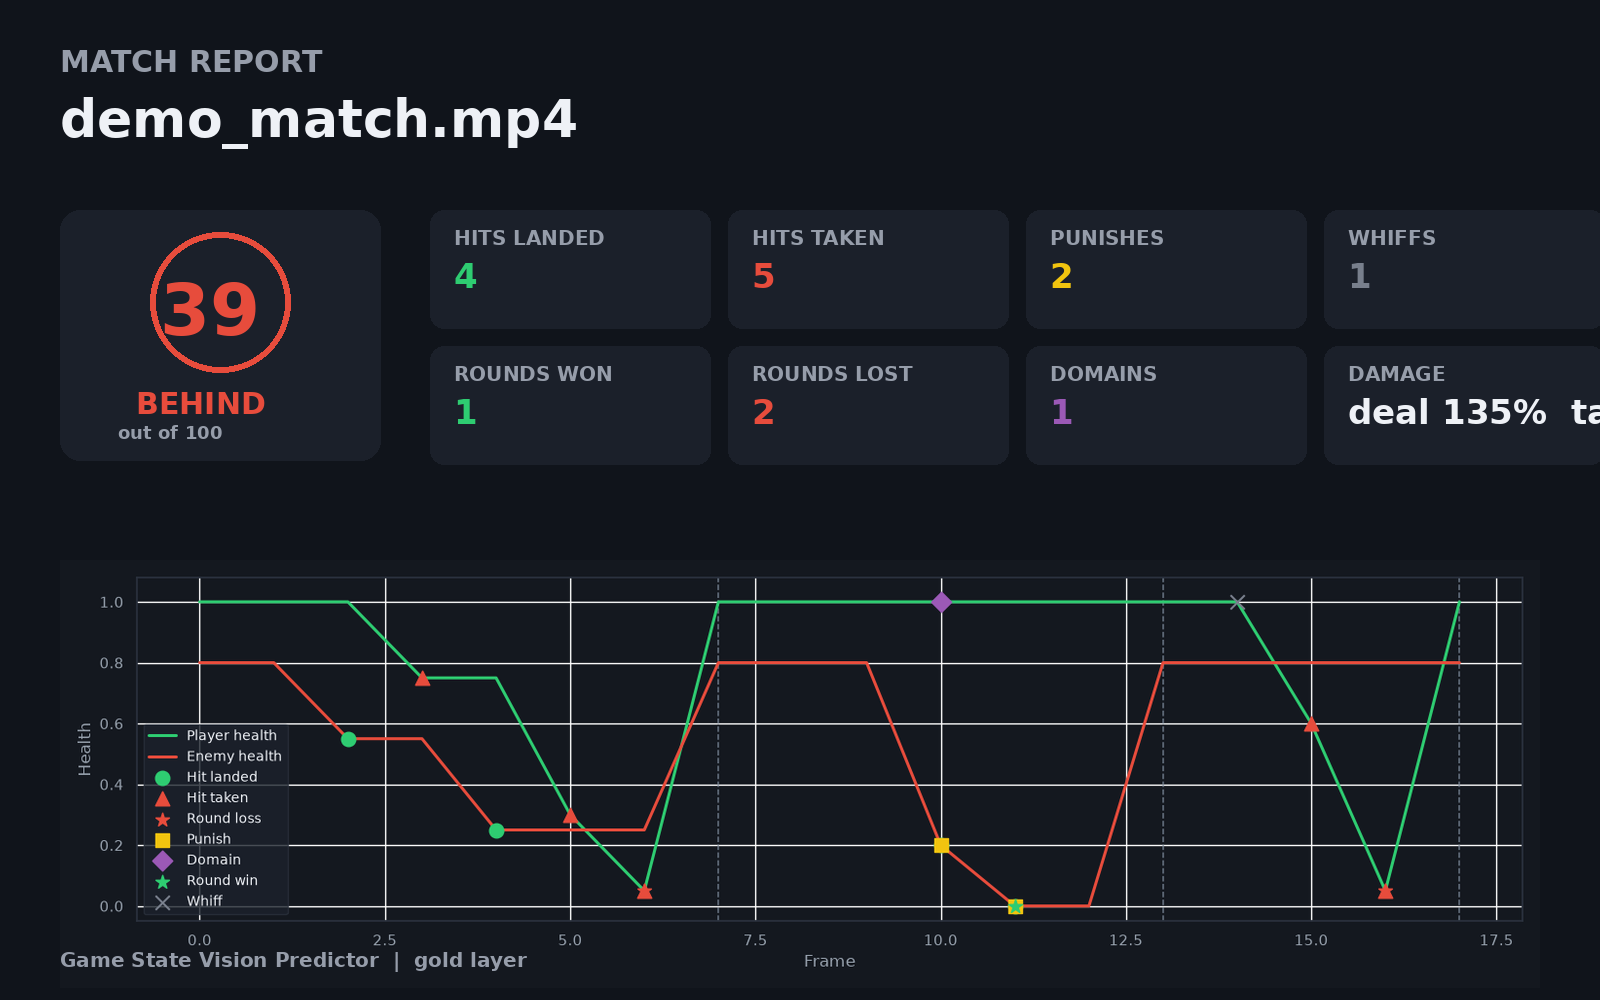

In [14]:
from IPython.display import Image as IPImage

IPImage(report_result["stat_card"], width=1100)

The card is one file — share it after the match. It shows the score badge,
the 8 headline stats, the health curves, and event markers (hits, punishes,
whiffs, round outcomes, domain deployments).

---

# Part 10: The State-Reader — a Versioned Model

The winning classifier is the product's **state-reader**. Registering it makes
every training round reproducible and promotable: train a new one, compare, and
flip `Staging` → `Production` when it earns it (no history lost).

`register_state_reader()` wraps the MLflow Model Registry with our domain name
(`state_reader`) and stamps the training metrics on the version.


In [15]:
# Fresh slate: drop any earlier state-reader so this demo is deterministic
# and re-runnable (versions 1, 2, 3 ... belong to this notebook only).
from mlflow.exceptions import MlflowException
import mlflow as _mlflow

try:
    _client = _mlflow.tracking.MlflowClient()
    for _v in _client.search_model_versions("name = 'state_reader'"):
        _client.delete_model_version("state_reader", _v.version)
    _client.delete_registered_model("state_reader")
    print("Cleared previous state_reader history")
except MlflowException:
    print("No previous state_reader history to clear")

version = register_state_reader(
    result["model_path"],
    tags={"accuracy": f"{result['accuracy']:.3f}",
          "macro_f1": f"{result['macro_f1']:.3f}",
          "model_name": result["model_name"]},
)
print("Registered:", version)

Cleared previous state_reader history
Registered: {'name': 'state_reader', 'version': 1, 'stage': 'Staging', 'run_id': 'dbf2ad4ce9244a588469ef2fcb30088e', 'tags': {'accuracy': '1.000', 'macro_f1': '1.000', 'model_name': 'random_forest'}}


/mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/src/pipeline/model_registry.py:81: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(name, str(version_number), stage)


In [16]:
print("All versions:")
for v in list_state_reader_versions():
    print(f"  v{v['version']}  stage={v['stage']:>10}  tags={v['tags']}")

production = transition_state_reader_version(version["version"], stage="Production")
print(f"\nPromoted: {production}")

state_reader = load_state_reader()   # loads the Production version
label, probs = predict(winning_example, state_reader)
print(f"\nState-reader -> {label} ({probs})")

All versions:
  v1  stage=   Staging  tags={'accuracy': '1.000', 'macro_f1': '1.000', 'model_name': 'random_forest'}

Promoted: {'name': 'state_reader', 'version': 1, 'stage': 'Production', 'run_id': 'dbf2ad4ce9244a588469ef2fcb30088e', 'tags': {'accuracy': '1.000', 'macro_f1': '1.000', 'model_name': 'random_forest'}}



State-reader -> winning ({'winning': 1.0, 'losing': 0.0, 'stalemate': 0.0})


/mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/src/pipeline/model_registry.py:103: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(name, str(model_version), stage)


---
# Part 11: The Complete Pipeline on a Real Screenshot

Now the full journey — Bronze → Silver → Gold — on a real screenshot from
`data/bronze/`. The real Silver reader is still heuristic, so treat its
features as a preview; the *mechanics* are exactly what runs on real VODs.


In [17]:
pngs = sorted(BRONZE_DIR.glob("*.png"))
if not pngs:
    raise FileNotFoundError(f"No PNGs found in {BRONZE_DIR}")

real_image = str(pngs[0])
print(f"Input : {pngs[0].name}")

from src.pipeline.silver import process_image as silver_process_image

bronze_process(real_image, str(SILVER_DIR))
silver_result = silver_process_image(real_image, str(SILVER_DIR))
features = silver_result["silver_features"]
print(f"Silver: player_health={features['player_health']:.2f}, "
      f"enemies={features['num_enemies']}, attacking={features['attacking']}, "
      f"defending={features['defending']}")

rule_label = rule_based_label(features)
predicted, probs = predict(features, model)

print(f"\nRule-based reference : {rule_label.upper()}")
print(f"Model prediction    : {predicted.upper()} (winning={probs['winning']:.2f})")
print("\nOn default/zero features the model is out of distribution - "
      "low-confidence OOD always signals 'collect more real data'.")

Input : Screenshot 2026-07-25 112239.png


Silver: player_health=0.60, enemies=6, attacking=False, defending=False

Rule-based reference : WINNING
Model prediction    : WINNING (winning=1.00)

On default/zero features the model is out of distribution - low-confidence OOD always signals 'collect more real data'.


---
# Exploring the Results in the MLflow UI

```
mlflow ui
```

then open http://localhost:5000. You will find:

- **gold_demo** — the model-zoo race: six runs, each with a confusion matrix
  and classification report, plus the `leaderboard` run with `leaderboard.csv`,
  `feature_correlations.png`, and `tsne_embedding.png`.
- **gold_vod_report** — one run per processed VOD: params (VOD file, event
  thresholds), metrics (event counts, mean OCR confidence, score), and the
  `timeline.json` / `stat_card.png` artifacts.
- **Model Registry → `state_reader`** — every registered classifier version,
  with its tags and lifecycle stage.

---

## Summary

- Gold classifies `winning` / `losing` / `stalemate`, then it records the story.
- The **event layer** turns state deltas into hits, punishes, whiffs, round
  outcomes, and domain alerts.
- The **report** produces a 0-100 score, a timeline JSON, and a shareable PIL
  separately card per match.
- Every processed VOD is a **per-VOD MLflow run** (timeline + stat card artifacts).
- The best classifier is registered as a **versioned state-reader** you can
  promote from Staging to Production after retraining.

## Next Steps

The bottleneck is now data, not code: collect 1000-2000 labeled real screenshots
(see `docs/data_collection_plan.md`), then retrain with

```python
train_and_compare("data/gold", experiment_name="gold_production")
```